In [7]:
# imports
import numpy as np
from astropy.timeseries import BoxLeastSquares
import h5py 
import matplotlib.pyplot as plt
import lightkurve as lk
from tqdm.auto import tqdm
import pandas as pd

/opt/homebrew/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# data download
with h5py.File("sector36_time_flux.mat", "r") as f:
    time = f["time"][:]
    flux = f["flux"][:]
    tic_id = f["TIC_ID"][:]

    tic_refs = tic_id[0]

    tic_ids = np.array([int("".join(chr(c) for c in f[ref][()].flatten()).replace("TIC", "")) for ref in tic_refs])

In [9]:
# inspecting shape
print(f'Time array shape: {time.shape}\nFlux array shape: {flux.shape}\nTIC ID array shape: {tic_id.shape}')

# squeezing the (1, x) arrays
time = time.squeeze()
tic_id = tic_id.squeeze()

Time array shape: (1, 3467)
Flux array shape: (22454, 3467)
TIC ID array shape: (1, 22454)


In [10]:
# Fraction of finite measurements for each light curve
finite_frac = np.mean(np.isfinite(flux), axis=1)
min_frac = 0.9

# Calculate median flux only for rows that contain at least one finite value
has_finite = np.any(np.isfinite(flux), axis=1)
med_flux = np.full(flux.shape[0], np.nan)
med_flux[has_finite] = np.nanmedian(flux[has_finite], axis=1)

# Light curves that have enough data and are safe to normalize
valid = (
    (finite_frac > min_frac) &
    np.isfinite(med_flux) &
    (med_flux != 0)
)

# Normalize only valid light curves
norm_flux = np.full(flux.shape, np.nan, dtype=float)
norm_flux[valid] = flux[valid] / med_flux[valid, None]

# Robust scatter estimate: median absolute deviation (MAD)
scatter_measure = np.full(flux.shape[0], np.nan)

med = np.nanmedian(norm_flux[valid], axis=1)

scatter_measure[valid] = np.nanmedian(
    np.abs(norm_flux[valid] - med[:, None]),
    axis=1
)

# Final quality mask
good = (
    valid &
    np.isfinite(scatter_measure) &
    (scatter_measure > 0)
)

print(f"{good.sum()} / {len(good)} light curves passed")


22131 / 22454 light curves passed


Total cadences: 3467
Kept cadences: 2292
Removed cadences: 1175
Fraction kept: 0.661


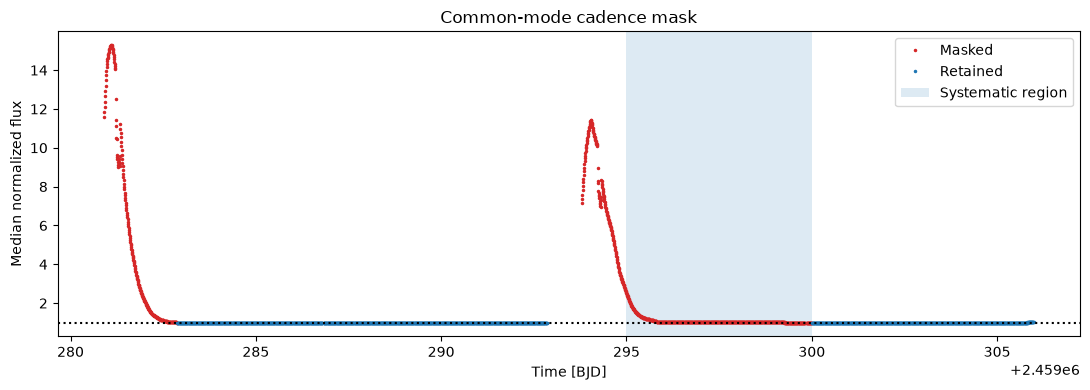

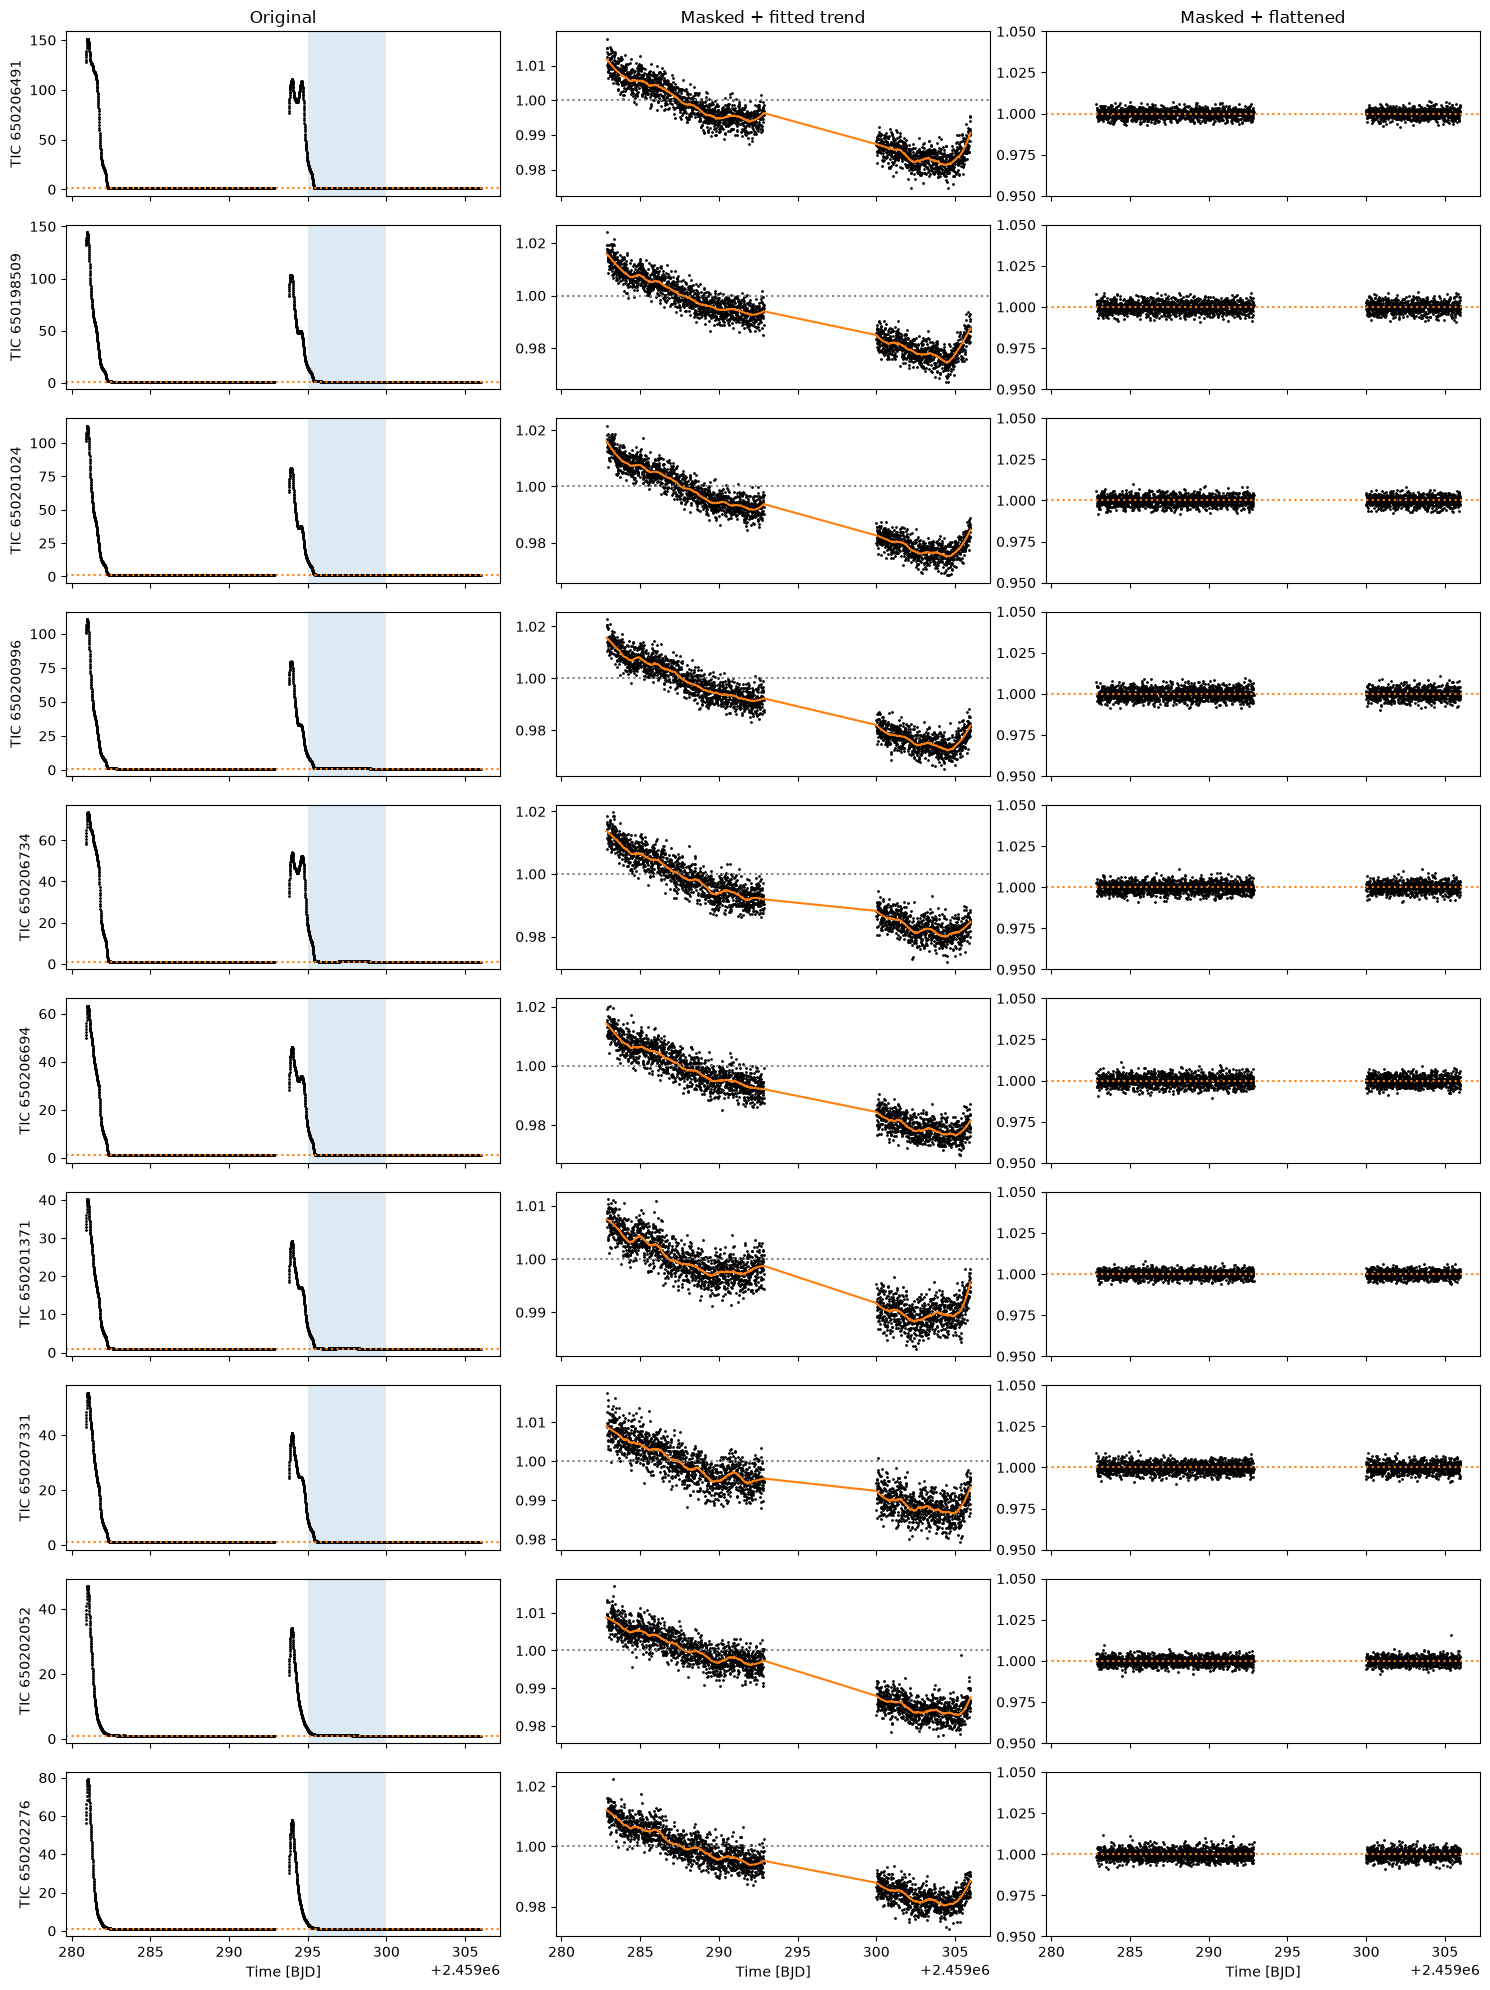

In [11]:
time = np.asarray(time).flatten()

# Build common-mode signal
common_mode = np.nanmedian(norm_flux[good], axis=0)
dcommon = np.abs(np.gradient(common_mode, time))

# Initial common-mode quality mask
stable = np.isfinite(common_mode) & (np.abs(common_mode - 1.0) < 0.05) & (dcommon < 0.05)

# Mask the large shared systematic/recovery feature
systematic_mask = (time >= 2459295.0) & (time <= 2459300.0)
stable = stable & ~systematic_mask

print(f"Total cadences: {len(time)}")
print(f"Kept cadences: {stable.sum()}")
print(f"Removed cadences: {(~stable).sum()}")
print(f"Fraction kept: {stable.mean():.3f}")

# Plot common-mode mask
plt.figure(figsize=(11, 4))
plt.plot(time[~stable], common_mode[~stable], ".", color="C3", ms=3, label="Masked")
plt.plot(time[stable], common_mode[stable], ".", color="C0", ms=3, label="Retained")
plt.axvspan(2459295.0, 2459300.0, alpha=0.15, label="Systematic region")
plt.axhline(1, color="black", ls=":")
plt.xlabel("Time [BJD]")
plt.ylabel("Median normalized flux")
plt.title("Common-mode cadence mask")
plt.legend()
plt.tight_layout()
plt.show()

# Test masking + flattening on 10 stars

test_inds = np.where(good)[0][:10]
fig, axes = plt.subplots(len(test_inds), 3, figsize=(15, 2 * len(test_inds)), sharex=True)
for row, i in enumerate(test_inds):
    finite = np.isfinite(norm_flux[i])
    valid = finite & stable
    lc = lk.LightCurve(time=time[valid], flux=norm_flux[i, valid])
    flat, trend = lc.flatten(window_length=201, polyorder=2, break_tolerance=5, return_trend=True)

    # Original
    axes[row, 0].plot(time[finite], norm_flux[i, finite], ".k", ms=2)
    axes[row, 0].axvspan(2459295.0, 2459300.0, alpha=0.15)
    axes[row, 0].axhline(1, color="C1", ls=":")
    axes[row, 0].set_ylabel(f"TIC {int(tic_ids[i])}")

    # Masked + fitted trend
    axes[row, 1].plot(lc.time.value, lc.flux.value, ".k", ms=2)
    axes[row, 1].plot(trend.time.value, trend.flux.value, color="C1", lw=1.5)
    axes[row, 1].axhline(1, color="0.5", ls=":")
    
    # Masked + flattened
    axes[row, 2].plot(flat.time.value, flat.flux.value, ".k", ms=2)
    axes[row, 2].axhline(1, color="C1", ls=":")
    axes[row, 2].set_ylim(0.95, 1.05)

axes[0, 0].set_title("Original")
axes[0, 1].set_title("Masked + fitted trend")
axes[0, 2].set_title("Masked + flattened")

for ax in axes[-1]:
    ax.set_xlabel("Time [BJD]")

plt.tight_layout()
plt.show()

In [ ]:
one_percent_drop_list = []

def initial_filter(i):
    valid = stable & np.isfinite(norm_flux[i])

    if np.sum(valid) < 100:
        return False

    t = np.asarray(time[valid], dtype=float)
    f = np.asarray(norm_flux[i, valid], dtype=float)
    lc = lk.LightCurve(time=t, flux=f)

    try:
        flat = lc.flatten(window_length=201, polyorder=2, break_tolerance=5)

    except Exception:
        return False

    t_flat = np.asarray(flat.time.value, dtype=float)
    f_flat = np.asarray(flat.flux.value, dtype=float)
    finite = np.isfinite(t_flat) & np.isfinite(f_flat)

    t_flat = t_flat[finite]
    f_flat = f_flat[finite]

    if len(t_flat) < 100:
        return False

    med_flat = np.nanmedian(f_flat)

    drop_count = np.sum(f_flat < 0.99 * med_flat)
    return drop_count >= 10

one_percent_drop_list = np.zeros(len(good), dtype=bool)

for i in tqdm(np.where(good)[0], desc="Filtering light curves"):
    one_percent_drop_list[i] = initial_filter(i)

print(f"{one_percent_drop_list.sum()} light curves passed the initial filter")

# Keep only light curves that passed both the original quality filter
# and the one-percent-drop filter.
good = good & one_percent_drop_list

print(f"{good.sum()} light curve also passed the filter of dropping 1% in at least 10 time points")
    


    

Searching light curves: 100%|██████████| 22131/22131 [13:29<00:00, 27.33it/s]



Successfully searched: 22131 stars
Median S/N: 5.02
Maximum S/N: 105023.76
S/N > 7: 2679

2060 candidates passed initial cuts
          tic     period            t0  duration_hours  depth_ppt         snr  \
0   816736865   0.894978  2.459283e+06             2.0  38.009440  320.180524   
1   847480908   2.228418  2.459284e+06             3.0  72.082259  309.142211   
2   871636380   2.647596  2.459285e+06             3.0  44.606654  295.001927   
3   859267560   3.119287  2.459284e+06             5.0  32.073340  231.375104   
4   860246735  17.118977  2.459287e+06             5.0  46.076359  214.249961   
5   737375112   1.090490  2.459283e+06             1.5  96.044728  181.852388   
6   814296972   2.434092  2.459285e+06             5.0  34.108335  180.129488   
7   726554203   0.850949  2.459284e+06             1.5  58.859657  152.203855   
8   685241967  16.140521  2.459285e+06             4.0  51.206214  139.397014   
9   940772701   0.788933  2.459284e+06             1.5  31.4631

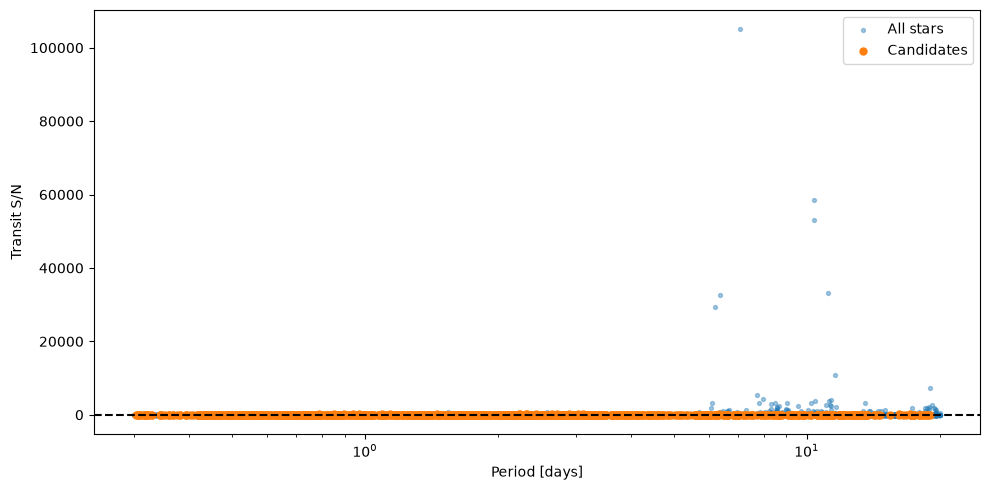

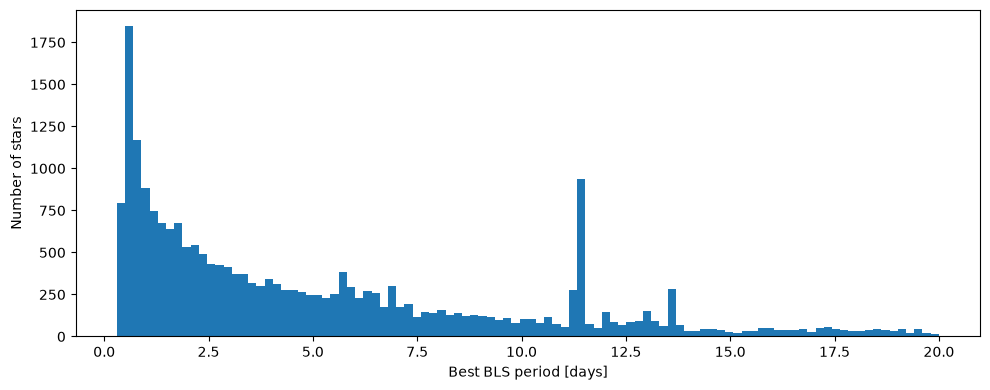

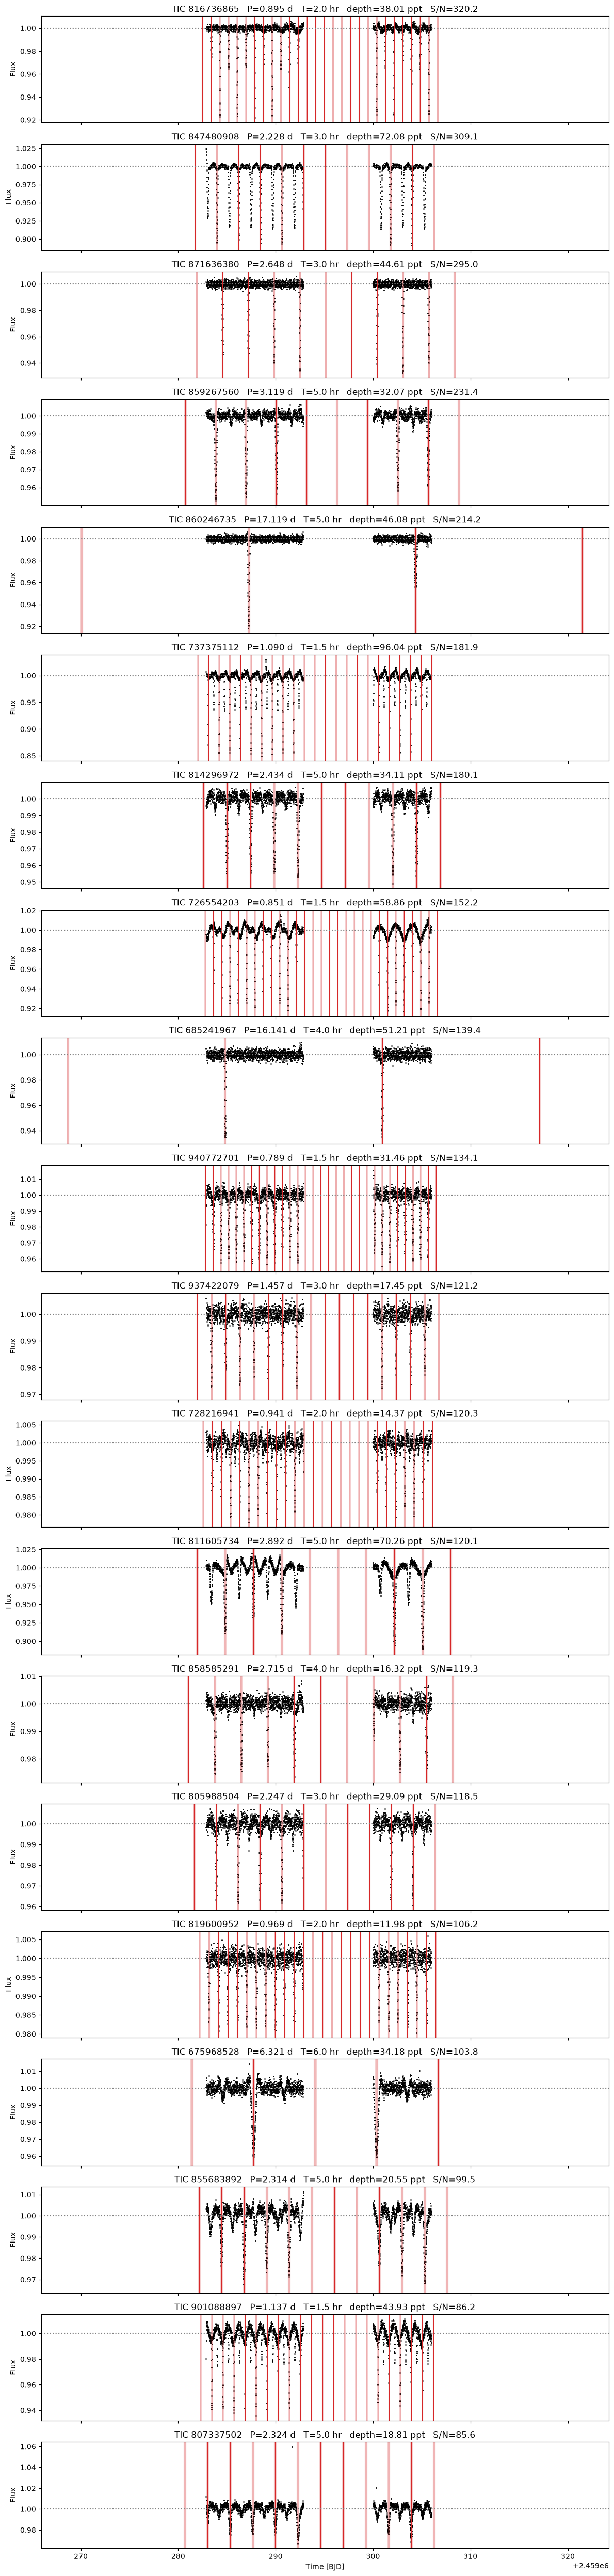

In [12]:
min_period = 0.1

max_period = 14.0

durations = np.linspace(0.1, 6.0, 50) / 24.0

period_grid = np.exp(np.linspace(np.log(min_period), np.log(max_period), 1000))

def search_one_star(i):

    valid = stable & np.isfinite(norm_flux[i])

    if np.sum(valid) < 100:
        return None

    t = np.asarray(time[valid], dtype=float)
    f = np.asarray(norm_flux[i, valid], dtype=float)
    lc = lk.LightCurve(time=t, flux=f)

    try:
        flat = lc.flatten(window_length=201, polyorder=2, break_tolerance=5)

    except Exception:
        return None

    t_flat = np.asarray(flat.time.value, dtype=float)
    f_flat = np.asarray(flat.flux.value, dtype=float)
    finite = np.isfinite(t_flat) & np.isfinite(f_flat)

    t_flat = t_flat[finite]
    f_flat = f_flat[finite]

    if len(t_flat) < 100:
        return None

    med_flat = np.nanmedian(f_flat)
    mad_flat = np.nanmedian(np.abs(f_flat - med_flat))
    sigma_flat = 1.4826 * mad_flat

    keep = f_flat < med_flat + 5 * sigma_flat

    t_flat = t_flat[keep]

    f_flat = f_flat[keep]
    
    bls = BoxLeastSquares(t_flat, f_flat)

    best_power = -np.inf

    best_period = np.nan

    best_t0 = np.nan

    best_duration = np.nan

    best_depth = np.nan

    best_depth_err = np.nan

    # Search each duration only over periods where duration / period < 0.1
    for duration in durations:
        allowed_periods = period_grid[period_grid > 10.0 * duration]
        if len(allowed_periods) == 0:
            continue
        try:
            power = bls.power(allowed_periods, duration)
        except Exception:
            continue
        if not np.any(np.isfinite(power.power)):
            continue
        k = np.nanargmax(power.power)

        if power.power[k] > best_power:
            best_power = float(power.power[k])
            best_period = float(power.period[k])
            best_t0 = float(power.transit_time[k])
            best_duration = float(power.duration[k])
            best_depth = float(power.depth[k])
            if hasattr(power, "depth_err"):
                best_depth_err = float(power.depth_err[k])

    if not np.isfinite(best_period):
        return None
    
    in_transit = bls.transit_mask(t_flat, best_period, best_duration, best_t0)
    n_in_transit = int(np.sum(in_transit))
    n_out_transit = int(np.sum(~in_transit))
    oot_flux = f_flat[~in_transit]

    if len(oot_flux) > 0:
        oot_med = np.nanmedian(oot_flux)
        mad_oot = np.nanmedian(np.abs(oot_flux - oot_med))
        sigma_oot = 1.4826 * mad_oot

    else:
        mad_oot = np.nan
        sigma_oot = np.nan

    if np.isfinite(sigma_oot) and sigma_oot > 0 and n_in_transit > 0:
        snr = best_depth / sigma_oot * np.sqrt(n_in_transit)

    else:
        snr = np.nan
    transit_numbers = np.round((t_flat[in_transit] - best_t0) / best_period).astype(int)

    if len(transit_numbers) > 0:
        unique_transits, counts = np.unique(transit_numbers, return_counts=True)
        n_transits = len(unique_transits)
        min_points_per_transit = int(np.min(counts))
        median_points_per_transit = float(np.median(counts))

    else:
        n_transits = 0
        min_points_per_transit = 0
        median_points_per_transit = 0

    return {
        "index": i,
        "tic": int(tic_ids[i]),
        "period": best_period,
        "t0": best_t0,
        "duration": best_duration,
        "duration_hours": best_duration * 24.0,
        "depth": best_depth,
        "depth_ppt": best_depth * 1000.0,
        "depth_err": best_depth_err,
        "power": best_power,
        "snr": snr,
        "sigma_oot": sigma_oot,
        "mad_oot": mad_oot,
        "n_transits": n_transits,
        "n_in_transit": n_in_transit,
        "n_out_transit": n_out_transit,
        "min_points_per_transit": min_points_per_transit,
        "median_points_per_transit": median_points_per_transit,
        "n_points": len(t_flat)
    }

# Test on 100 stars

good_inds = np.where(good)[0]#[:100]

results_list = []

for i in tqdm(good_inds, desc="Searching light curves"):
    result = search_one_star(i)
    if result is not None:
        results_list.append(result)

results = pd.DataFrame(results_list)

print(f"\nSuccessfully searched: {len(results)} stars")
print(f"Median S/N: {results['snr'].median():.2f}")
print(f"Maximum S/N: {results['snr'].max():.2f}")
print(f"S/N > 7: {(results['snr'] > 7).sum()}")

candidate_mask = np.isfinite(results["snr"]) & (results["snr"] > 7) & (results["n_transits"] >= 2) & (results["n_in_transit"] >= 10) & (results["min_points_per_transit"] >= 2) & (results["depth"] > 0) & (results["depth"] < 0.10)
candidates = results[candidate_mask].copy()
candidates = candidates.sort_values("snr", ascending=False).reset_index(drop=True)
print(f"\n{len(candidates)} candidates passed initial cuts")

print(candidates[["tic", "period", "t0", "duration_hours", "depth_ppt", "snr", "n_transits", "n_in_transit"]].head(50))
results.to_csv("bls_search_results.csv", index=False)
candidates.to_csv("bls_candidate_shortlist.csv", index=False)

plt.figure(figsize=(10, 5))
plt.scatter(results["period"], results["snr"], s=8, alpha=0.4, label="All stars")
plt.scatter(candidates["period"], candidates["snr"], s=25, label="Candidates")
plt.axhline(7, color="black", ls="--")
plt.xlabel("Period [days]")
plt.ylabel("Transit S/N")
plt.xscale("log")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(results["period"], bins=100)
plt.xlabel("Best BLS period [days]")
plt.ylabel("Number of stars")
plt.tight_layout()
plt.show()

# Plot up to the 20 strongest candidates with predicted transits

plot_candidates = candidates.head(20)

if len(plot_candidates) > 0:
    fig, axes = plt.subplots(len(plot_candidates), 1, figsize=(12, 2.5 * len(plot_candidates)), sharex=True)
    if len(plot_candidates) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, plot_candidates.iterrows()):
        i = int(row["index"])
        period = row["period"]
        t0 = row["t0"]
        duration = row["duration"]
        valid = stable & np.isfinite(norm_flux[i])
        lc = lk.LightCurve(time=time[valid], flux=norm_flux[i, valid])
        flat = lc.flatten(window_length=201, polyorder=2, break_tolerance=5)
        t_flat = np.asarray(flat.time.value)
        f_flat = np.asarray(flat.flux.value)
        ax.plot(t_flat, f_flat, ".k", ms=2)
        n_min = int(np.floor((np.min(t_flat) - t0) / period))
        n_max = int(np.ceil((np.max(t_flat) - t0) / period))
        transit_times = t0 + np.arange(n_min, n_max + 1) * period
        
        for tt in transit_times:
            ax.axvline(tt, color="C3", lw=1)
            ax.axvspan(tt - duration / 2, tt + duration / 2, color="C3", alpha=0.15)
        ax.axhline(1, color="0.5", ls=":")
        ax.set_ylabel("Flux")
        ax.set_title(f"TIC {int(row['tic'])}   P={period:.3f} d   T={duration * 24:.1f} hr   depth={row['depth_ppt']:.2f} ppt   S/N={row['snr']:.1f}")
    axes[-1].set_xlabel("Time [BJD]")
    plt.tight_layout()
    plt.show()